In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import openpyxl as opx


In [2]:
df = pd.read_excel("dados-cti.xlsx")   
print(df.head()) 

                Nome-Card Data-Inicio   Data-Fim  Dias-Uteis  Dias-Corridos  \
0             Alinhamento  2026-03-02 2026-03-03         1.0            1.0   
1                Kick-Off  2026-03-03 2026-03-04         1.0            1.0   
2            Configuração  2026-03-03 2026-03-04         1.0            1.0   
3            Double Check         NaT 2026-03-04         NaN            NaN   
4  Encaminhar dispositivo  2026-03-05 2026-03-09         2.0            4.0   

   Atrasado  
0     False  
1     False  
2     False  
3     False  
4      True  


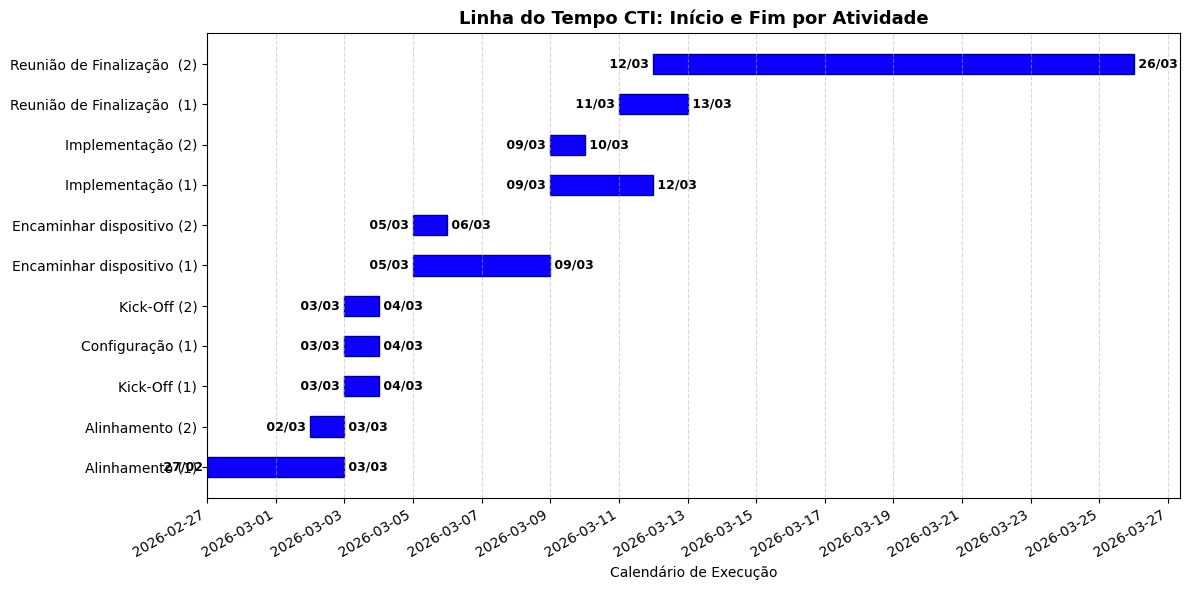

In [ ]:
# 1. Filtrar linhas onde as datas e dias estão preenchidos para não quebrar o gráfico
df_gantt = df.dropna(subset=["Data-Inicio", "Data-Fim", "Dias-Corridos"]).copy()

# Garantir que estão no formato de data real do Pandas
df_gantt["Data-Inicio"] = pd.to_datetime(df_gantt["Data-Inicio"])
df_gantt["Data-Fim"] = pd.to_datetime(df_gantt["Data-Fim"])

# Ordenar cronologicamente do primeiro ao último card para a linha do tempo fazer sentido
df_gantt = df_gantt.sort_values(by="Data-Inicio", ascending=True)

# Corrigir o caractere corrompido que veio do Excel ("ImplementaÃ§Ã£o")
df_gantt["Nome-Card"] = df_gantt["Nome-Card"].astype(str).str.replace("ImplementaÃ§Ã£o", "Implementação")

# Criar um nome único para o eixo Y para evitar o erro de colunas duplicadas
# (Adiciona um número se o card se repetir, ex: "Kick-Off (1)", "Kick-Off (2)")
ocorrencias = df_gantt.groupby("Nome-Card").cumcount() + 1
df_gantt["Card_Unico"] = df_gantt["Nome-Card"] + " (" + ocorrencias.astype(str) + ")"

# 2. Configurar a plotagem
fig, ax = plt.subplots(figsize=(12, 6))

# Desenhar as barras horizontais (Gantt)
ax.barh(
    df_gantt["Card_Unico"], 
    left=df_gantt["Data-Inicio"], 
    width=df_gantt["Data-Fim"] - df_gantt["Data-Inicio"], 
    color="#0d00ff", 
    edgecolor="navy",
    height=0.5
)

# 3. Adicionar as datas escritas (dia/mês) nas pontas de cada barra
for i, row in enumerate(df_gantt.itertuples(index=False)):
    # row[1] é Data-Inicio, row[2] é Data-Fim
    data_ini_txt = row[1].strftime('%d/%m')
    data_fim_txt = row[2].strftime('%d/%m')
    
    # Texto azul escuro na esquerda (Início)
    ax.text(row[1], i, f" {data_ini_txt} ", va='center', ha='right', fontsize=9, fontweight='bold', color="#000000")
    # Texto vermelho na direita (Fim)
    ax.text(row[2], i, f" {data_fim_txt}", va='center', ha='left', fontsize=9, fontweight='bold', color="#000000")

# 4. Formatar o eixo X para mostrar o calendário de forma espaçada
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2)) # Marcações a cada 2 dias no calendário
plt.xticks(rotation=30, ha='right')

plt.title("Linha do Tempo CTI: Início e Fim por Atividade", fontweight="bold", fontsize=13)
plt.xlabel("Calendário de Execução")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#importar a imagem gerada 


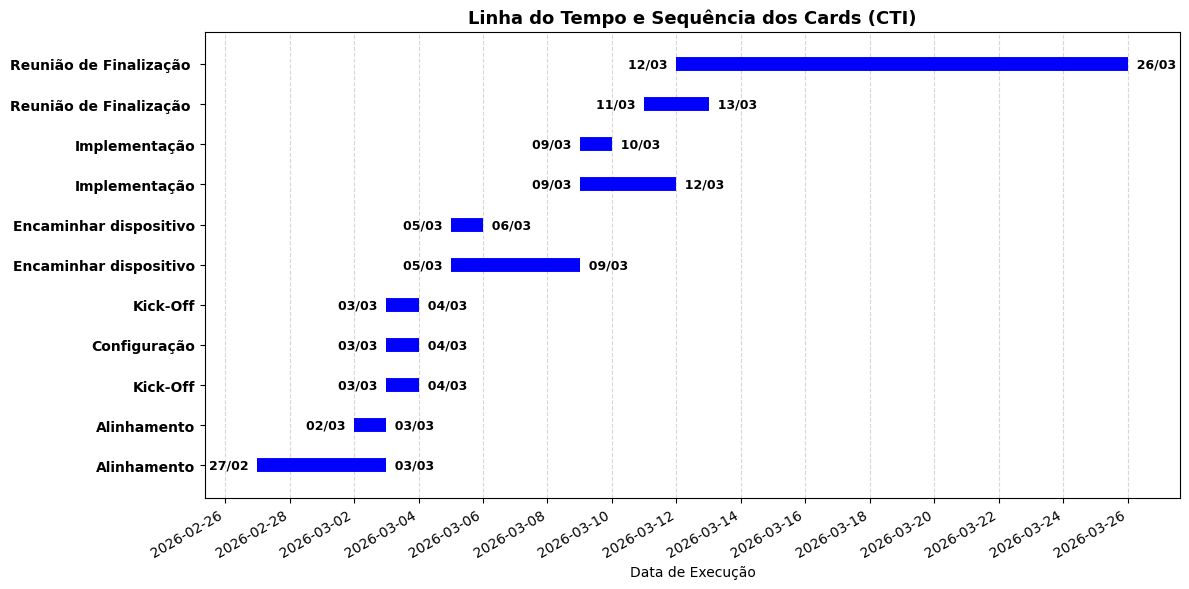

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Garantir que as datas estão no formato correto, tratar nulos e ordenar cronologicamente
df_cronologico = df.dropna(subset=["Data-Inicio", "Data-Fim"]).copy()
df_cronologico["Data-Inicio"] = pd.to_datetime(df_cronologico["Data-Inicio"])
df_cronologico["Data-Fim"] = pd.to_datetime(df_cronologico["Data-Fim"])
df_cronologico = df_cronologico.sort_values(by="Data-Inicio")

# Limpar caracteres de acentuação se houver (ex: Implementação)
df_cronologico["Nome-Card"] = df_cronologico["Nome-Card"].astype(str).str.replace("ImplementaÃ§Ã£o", "Implementação")

# 2. Configurar a figura e o eixo
fig, ax = plt.subplots(figsize=(12, 6))

# SOLUÇÃO CRÍTICA: Plotar usando o índice numérico (range) para que cada atividade tenha sua própria linha
ax.hlines(
    y=range(len(df_cronologico)),
    xmin=df_cronologico["Data-Inicio"],
    xmax=df_cronologico["Data-Fim"],
    color="blue",
    linewidth=10,
    zorder=2
)

# Substituir os números do eixo Y pelos nomes dos cards originais e limpos
ax.set_yticks(range(len(df_cronologico)))
ax.set_yticklabels(df_cronologico["Nome-Card"], fontsize=10, fontweight="bold")

# 3. Adicionar o bloco de textos com as datas usando o índice i para garantir o alinhamento e contraste
for i, row in enumerate(df_cronologico.itertuples(index=False)):
    # row[1] é Data-Inicio, row[2] é Data-Fim
    data_ini_txt = row[1].strftime('%d/%m')
    data_fim_txt = row[2].strftime('%d/%m')
    
    # Texto na esquerda (Início) - Alinhado perfeitamente com a linha exclusiva de índice 'i'
    ax.text(row[1], i, f"{data_ini_txt}  ", va='center', ha='right', fontsize=9, fontweight='bold', color="#000000")
    
    # Texto na direita (Fim) - Alinhado perfeitamente com a linha exclusiva de índice 'i'
    ax.text(row[2], i, f"  {data_fim_txt}", va='center', ha='left', fontsize=9, fontweight='bold', color="#000000")

# 4. Formatação dos eixos e calendário
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2)) # Intervalo a cada 2 dias
plt.xticks(rotation=30, ha='right')

plt.title("Linha do Tempo e Sequência dos Cards (CTI)", fontweight="bold", fontsize=13)
plt.xlabel("Data de Execução")
plt.grid(axis="x", linestyle="--", alpha=0.5, zorder=1)

# Margem vertical e horizontal para os textos não tocarem na borda da imagem
ax.margins(x=0.06, y=0.08)

plt.tight_layout()
plt.show()

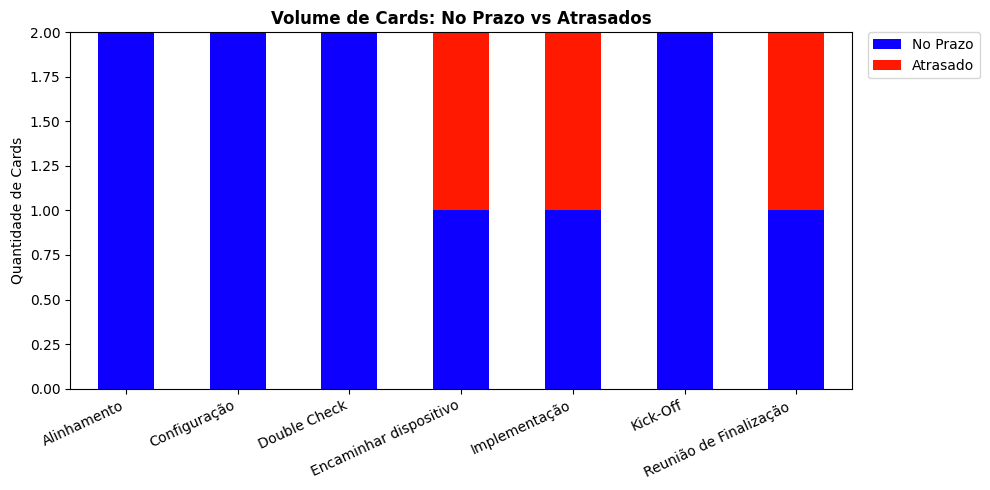

In [24]:
# 1. Copiar os dados e limpar os caracteres corrompidos dos nomes dos cards
df_limpo = df.copy()
df_limpo['Nome-Card'] = df_limpo['Nome-Card'].astype(str).str.replace("ImplementaÃ§Ã£o", "Implementação")

# 2. Criar a tabela cruzada (Card vs Atrasado) de forma direta
proporcao_atraso = pd.crosstab(df_limpo['Nome-Card'], df_limpo['Atrasado'])

# 3. Plotar em barras empilhadas com código limpo
ax = proporcao_atraso.plot(kind='bar', stacked=True, color=["#0d00ff", "#ff1900"], figsize=(10, 5))

# Ajustes finos nos rótulos e no título
plt.title('Volume de Cards: No Prazo vs Atrasados', fontweight='bold', fontsize=12)
plt.ylabel('Quantidade de Cards')
plt.xlabel('')
plt.xticks(rotation=25, ha='right')

# CORREÇÃO CRÍTICA: Move a legenda para fora do gráfico (canto superior direito)
plt.legend(['No Prazo', 'Atrasado'], bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

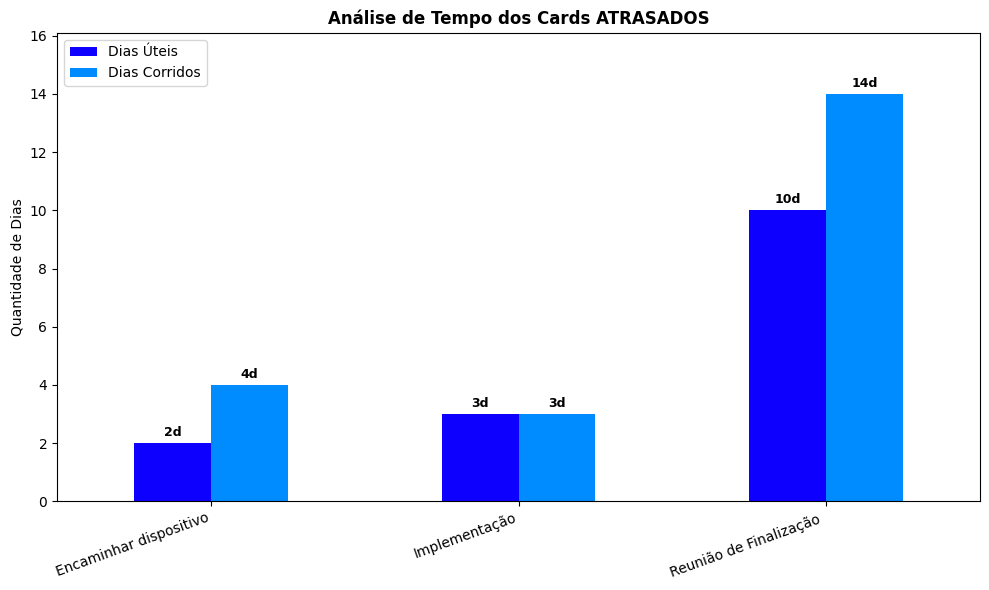

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filtrar apenas as linhas de cards atrasados
df_atrasados = df[df["Atrasado"].astype(str).str.upper() == "TRUE"].copy()

# Ajustar a acentuação de caracteres diretamente no texto para o gráfico
df_atrasados["Nome-Card"] = df_atrasados["Nome-Card"].astype(str).str.replace("ImplementaÃ§Ã£o", "Implementação")

# 2. Plotar usando o índice numérico para evitar bugs com nomes duplicados
ax = df_atrasados[["Dias-Uteis", "Dias-Corridos"]].plot(
    kind="bar", color=["#0d00ff", "#008cff"], figsize=(10, 6)
)

# 3. Substituir os números do eixo X pelos nomes dos cards LIMPOS (sem o número entre parênteses)
ax.set_xticklabels(df_atrasados["Nome-Card"], rotation=20, ha="right")

# 4. Adicionar as marcas de dias inteiros no topo de cada barra individual
for container in ax.containers:
    ax.bar_label(container, fmt="%.0fd", padding=3, fontsize=9, fontweight="bold")

# Customizações e legendas do gráfico
plt.title("Análise de Tempo dos Cards ATRASADOS", fontsize=12, fontweight="bold")
plt.ylabel("Quantidade de Dias")
plt.xlabel("")
plt.legend(["Dias Úteis", "Dias Corridos"])

# Folga no topo para o texto não encostar na borda
plt.ylim(0, df_atrasados["Dias-Corridos"].max() * 1.15)

plt.tight_layout()
plt.show()

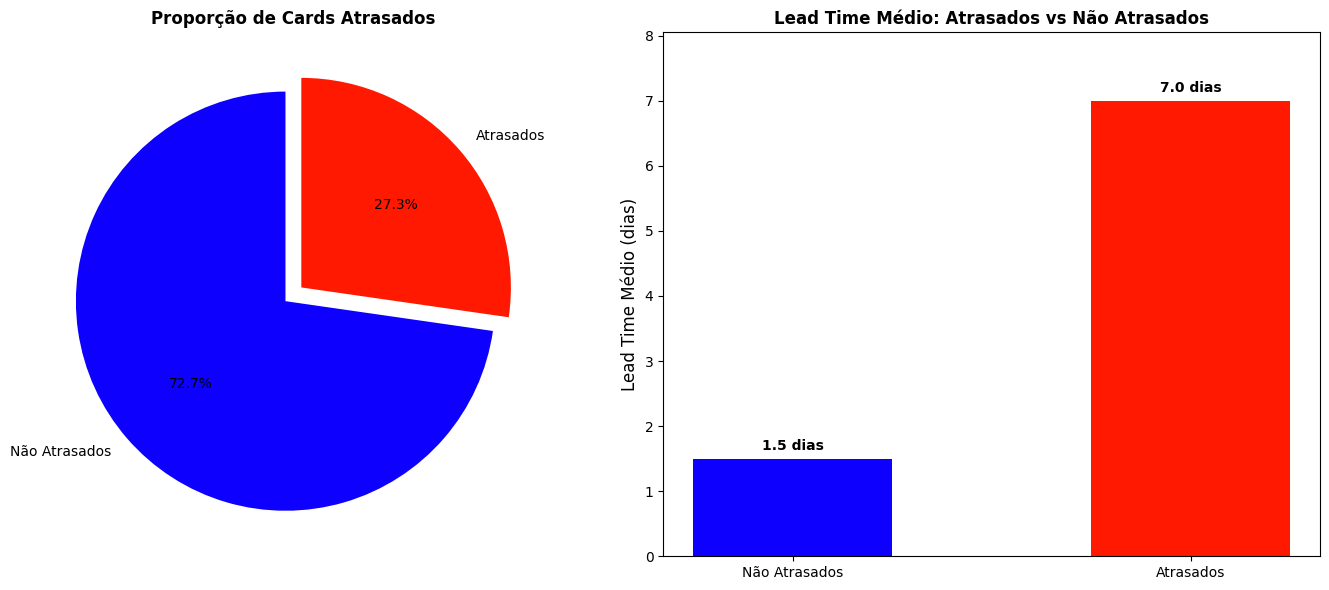

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Garantir que as colunas e os dados de atraso estão tratados no df atual
df_limpo = df.dropna(subset=["Atrasado", "Dias-Corridos"]).copy()

# Converter a coluna Atrasado para string padronizada para evitar divergências
df_limpo["Atrasado_Str"] = df_limpo["Atrasado"].astype(str).str.upper().str.strip()

# Calcular as quantidades exatas para o gráfico de pizza
qtd_atrasados = len(df_limpo[df_limpo["Atrasado_Str"] == "TRUE"])
qtd_nao_atrasados = len(df_limpo[df_limpo["Atrasado_Str"] == "FALSE"])

# Agrupar a média de Dias-Corridos (que funciona como o seu Lead Time nessa base)
# Mapeamos 'FALSE' para Não Atrasados e 'TRUE' para Atrasados
lead_time_atrasados = df_limpo.groupby("Atrasado_Str")["Dias-Corridos"].mean()

# Garantir que os índices existem no grupo para não gerar erro de ordenação no gráfico
media_nao_atrasados = lead_time_atrasados.get("FALSE", 0)
media_atrasados = lead_time_atrasados.get("TRUE", 0)


# 2. Configurar a estrutura de Subplots (1 linha, 2 colunas)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cores_pizza = ["#0d00ff", "#ff1900"]
labels = ['Não Atrasados', 'Atrasados']
sizes = [qtd_nao_atrasados, qtd_atrasados]

# Gráfico 1: Pizza (Proporção)
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=cores_pizza, startangle=90, explode=(0.05, 0.05))
axes[0].set_title('Proporção de Cards Atrasados', fontsize=12, fontweight='bold')

# Gráfico 2: Barras (Impacto no Lead Time)
valores_barra = [media_nao_atrasados, media_atrasados]
axes[1].bar(labels, valores_barra, color=cores_pizza, width=0.5)
axes[1].set_ylabel('Lead Time Médio (dias)', fontsize=12)
axes[1].set_title('Lead Time Médio: Atrasados vs Não Atrasados', fontsize=12, fontweight='bold')

# Adicionar os rótulos de texto em cima das barras
for i, v in enumerate(valores_barra):
    axes[1].text(i, v + (max(valores_barra) * 0.02), f'{v:.1f} dias', ha='center', fontsize=10, fontweight='bold')

# Dar uma folga no topo do gráfico de barras para o texto não cortar
axes[1].set_ylim(0, max(valores_barra) * 1.15)

# 3. Finalizar e salvar
plt.tight_layout()
plt.savefig('insight_2_atrasados.png', dpi=150, bbox_inches='tight')
plt.show()

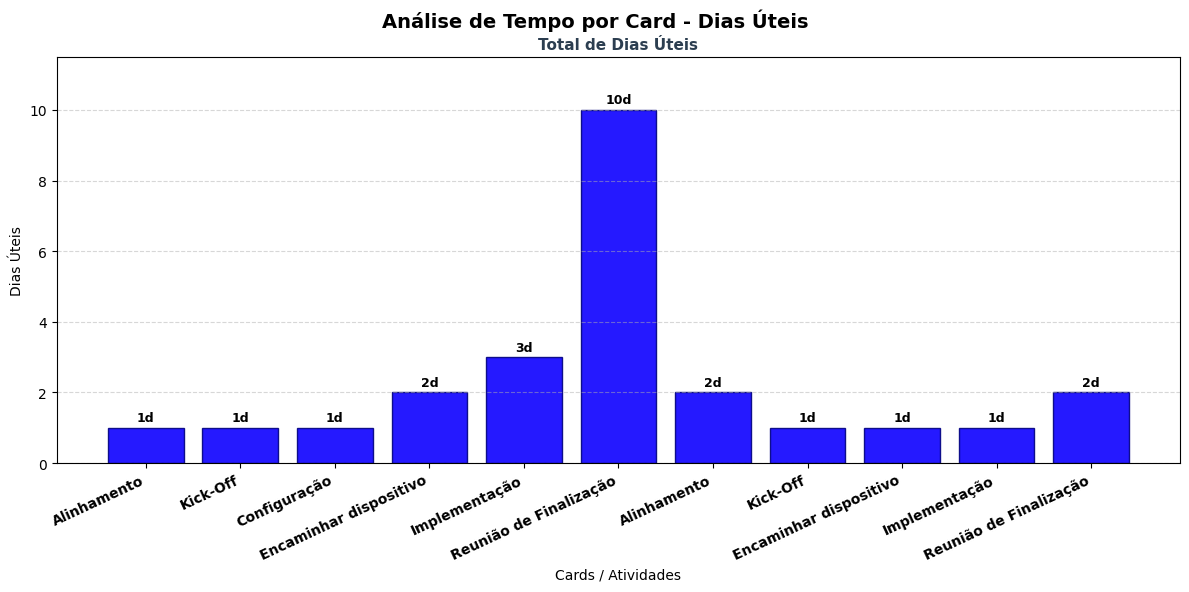

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filtrar linhas onde os tempos estão preenchidos para não quebrar a plotagem
df_limpo = df.dropna(subset=["Dias-Uteis"]).copy()

# Corrigir a acentuação dos nomes dos cards
df_limpo["Nome-Card"] = df_limpo["Nome-Card"].astype(str).str.strip().str.replace("ImplementaÃ§Ã£o", "Implementação")

# 2. Configurar a estrutura do Gráfico (Apenas 1 gráfico)
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Análise de Tempo por Card - Dias Úteis", fontsize=14, fontweight='bold')

# Criar a lista de posições físicas para o eixo X
posicoes = range(len(df_limpo))

# --- GRÁFICO: Dias Úteis (Tempo de Trabalho) ---
# Azul Escuro da empresa (#0d00ff)
ax.bar(posicoes, df_limpo["Dias-Uteis"], color="#0d00ff", edgecolor="navy", alpha=0.9)
ax.set_title("Total de Dias Úteis", fontsize=11, fontweight='bold', color="#2c3e50")
ax.set_ylabel("Dias Úteis")
ax.grid(axis="y", linestyle="--", alpha=0.5)

# Adicionar os rótulos de dias no topo de cada barra
for i, v in enumerate(df_limpo["Dias-Uteis"]):
    ax.text(i, v + (df_limpo["Dias-Uteis"].max() * 0.01), f"{v:.0f}d", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(0, df_limpo["Dias-Uteis"].max() * 1.15)

# 3. Formatar o eixo X para mostrar os nomes limpos
plt.xticks(posicoes, df_limpo["Nome-Card"], rotation=25, ha='right', fontsize=10, fontweight='bold')
plt.xlabel("Cards / Atividades")

# Ajustar o layout para não cortar nenhuma escrita ou legenda
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

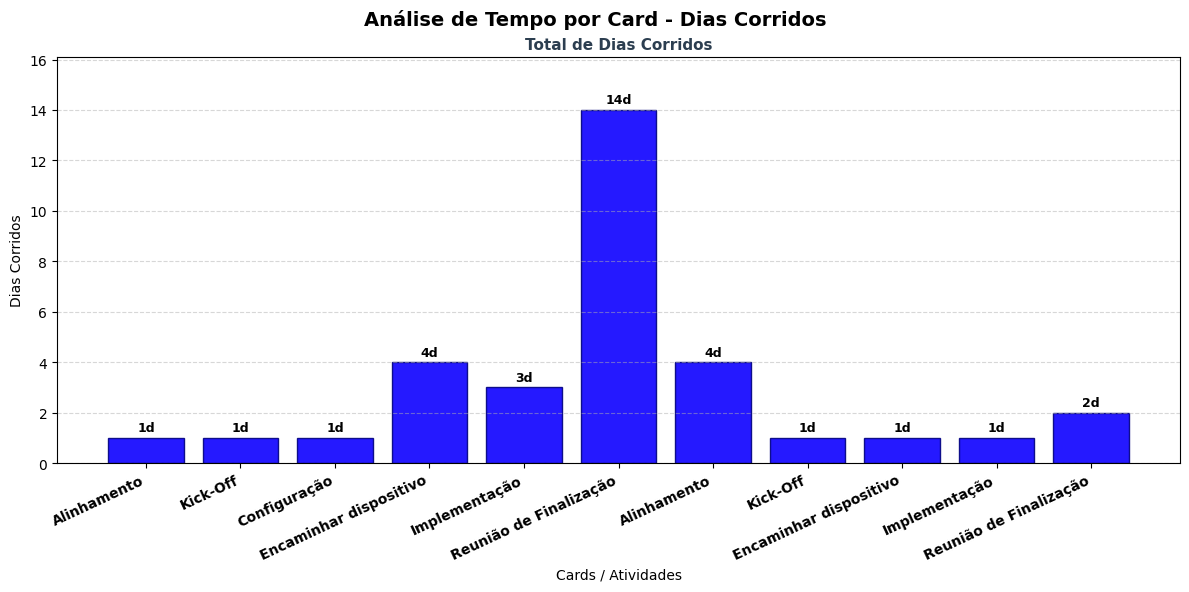

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filtrar linhas onde os tempos estão preenchidos para não quebrar a plotagem
df_limpo = df.dropna(subset=["Dias-Corridos"]).copy()

# Corrigir a acentuação dos nomes dos cards
df_limpo["Nome-Card"] = df_limpo["Nome-Card"].astype(str).str.strip().str.replace("ImplementaÃ§Ã£o", "Implementação")

# 2. Configurar a estrutura do Gráfico (Apenas 1 gráfico)
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Análise de Tempo por Card - Dias Corridos", fontsize=14, fontweight='bold')

# Criar a lista de posições físicas para o eixo X
posicoes = range(len(df_limpo))

# --- GRÁFICO: Dias Corridos (Tempo Total) ---
# Azul Claro da empresa (#008cff)
ax.bar(posicoes, df_limpo["Dias-Corridos"], color="#0d00ff", edgecolor="navy", alpha=0.9)
ax.set_title("Total de Dias Corridos", fontsize=11, fontweight='bold', color="#2c3e50")
ax.set_ylabel("Dias Corridos")
ax.grid(axis="y", linestyle="--", alpha=0.5)

# Adicionar os rótulos de dias no topo de cada barra
for i, v in enumerate(df_limpo["Dias-Corridos"]):
    ax.text(i, v + (df_limpo["Dias-Corridos"].max() * 0.01), f"{v:.0f}d", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(0, df_limpo["Dias-Corridos"].max() * 1.15)

# 3. Formatar o eixo X para mostrar os nomes limpos
plt.xticks(posicoes, df_limpo["Nome-Card"], rotation=25, ha='right', fontsize=10, fontweight='bold')
plt.xlabel("Cards / Atividades")

# Ajustar o layout para não cortar nenhuma escrita ou legenda
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

C:\Users\gusta\AppData\Local\Temp\ipykernel_7428\615249094.py:48: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gusta\AppData\Local\Temp\ipykernel_7428\615249094.py:48: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gusta\AppData\Local\Temp\ipykernel_7428\615249094.py:49: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('grafico_dependencia.png', dpi=150, bbox_inches='tight')
C:\Users\gusta\AppData\Local\Temp\ipykernel_7428\615249094.py:49: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('grafico_dependencia.png', dpi=150, bbox_inches='tight')
c:\Users\gusta\Desktop\pythonexec\clone\teste etl\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(b

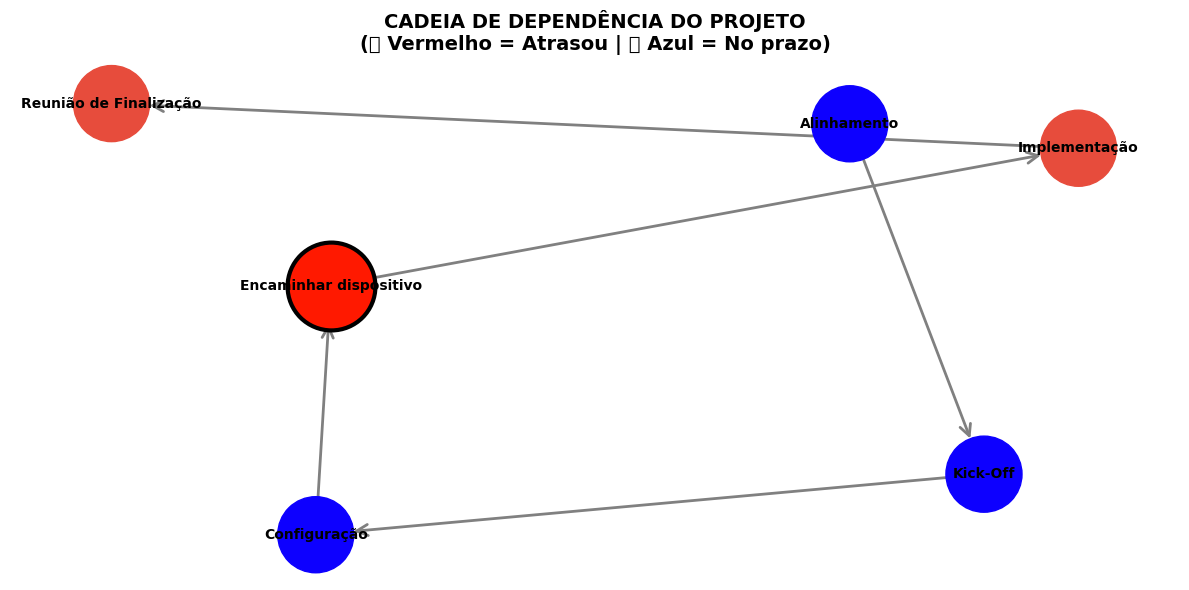

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Criar estrutura de dependência (baseada no seu PDF)
dependencias = [
    ("Alinhamento", "Kick-Off"),
    ("Kick-Off", "Configuração"),
    ("Configuração", "Encaminhar dispositivo"),
    ("Encaminhar dispositivo", "Implementação"),
    ("Implementação", "Reunião de Finalização"),
]

# Status: True = atrasou, False = no prazo
status_atraso = {
    "Alinhamento": False,
    "Kick-Off": False,
    "Configuração": False,
    "Encaminhar dispositivo": True,  # GARGALO
    "Implementação": True,
    "Reunião de Finalização": True,
}

# Criar gráfico
fig, ax = plt.subplots(figsize=(12, 6))
G = nx.DiGraph()
G.add_edges_from(dependencias)

# Definir cores: vermelho = atrasou, verde = no prazo
cores = ['#e74c3c' if status_atraso.get(node, False) else "#0d00ff" for node in G.nodes()]

# Posicionamento manual para ficar legível
pos = nx.spring_layout(G, seed=42, k=2)

nx.draw(G, pos, with_labels=True, node_color=cores, node_size=3000, 
        font_size=10, font_weight='bold', arrows=True, 
        arrowstyle='->', arrowsize=20, edge_color='gray', width=2)

# Destacar o gargalo principal
gargalo = "Encaminhar dispositivo"
nx.draw_networkx_nodes(G, pos, nodelist=[gargalo], node_color="#ff1900", 
                       node_size=4000, edgecolors='black', linewidths=3)

ax.set_title("CADEIA DE DEPENDÊNCIA DO PROJETO\n(🔴 Vermelho = Atrasou | 🟢 Azul = No prazo)", 
             fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig('grafico_dependencia.png', dpi=150, bbox_inches='tight')
plt.show()

📊 TABELA DE PRIORIZAÇÃO DE GARGALOS
                 Gargalo  Impacto (dias perdidos)  Facilidade de resolver (1-5) Prioridade  Score
  Reunião de Finalização                       12                             2      Média     48
  Encaminhar dispositivo                        4                             3       Alta     12
Configuração (duplicada)                        2                             5      Baixa      2


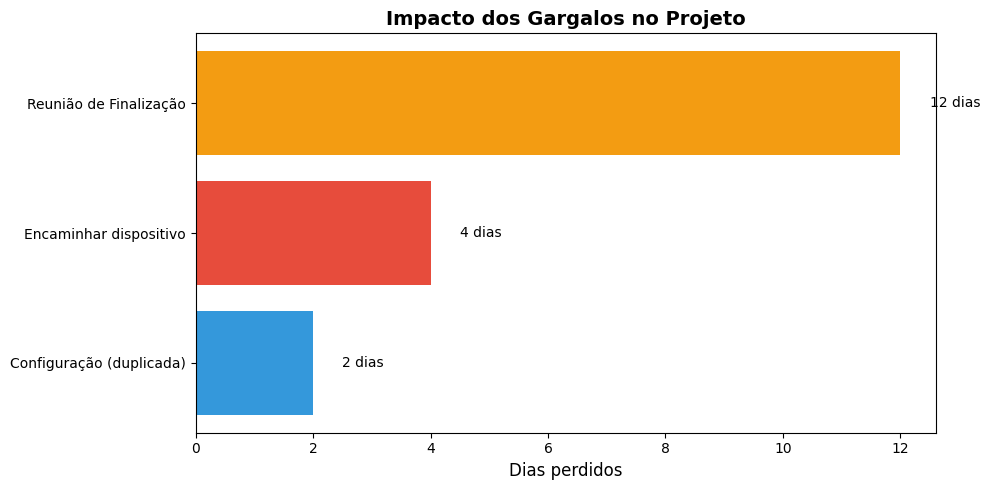

In [3]:
import pandas as pd

# Dados dos gargalos (baseados no seu arquivo)
gargalos = pd.DataFrame({
    'Gargalo': ['Encaminhar dispositivo', 'Reunião de Finalização', 'Configuração (duplicada)'],
    'Impacto (dias perdidos)': [4, 12, 2],
    'Facilidade de resolver (1-5)': [3, 2, 5],  # 5 = fácil
    'Prioridade': ['Alta', 'Média', 'Baixa']
})

# Calcular score de prioridade
gargalos['Score'] = gargalos['Impacto (dias perdidos)'] * (6 - gargalos['Facilidade de resolver (1-5)'])

# Ordenar por prioridade
gargalos = gargalos.sort_values('Score', ascending=False)

print("=" * 60)
print("📊 TABELA DE PRIORIZAÇÃO DE GARGALOS")
print("=" * 60)
print(gargalos.to_string(index=False))

# Gráfico de impacto
fig, ax = plt.subplots(figsize=(10, 5))
cores_impacto = ['#e74c3c' if p == 'Alta' else '#f39c12' if p == 'Média' else '#3498db' 
                 for p in gargalos['Prioridade']]
ax.barh(gargalos['Gargalo'], gargalos['Impacto (dias perdidos)'], color=cores_impacto)
ax.set_xlabel('Dias perdidos', fontsize=12)
ax.set_title('Impacto dos Gargalos no Projeto', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, v in enumerate(gargalos['Impacto (dias perdidos)']):
    ax.text(v + 0.5, i, f'{v} dias', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('impacto_gargalos.png', dpi=150, bbox_inches='tight')
plt.show()

🔍 ANÁLISE DE CAUSA RAIZ (Efeito Dominó)
                 Etapa  Planejado (dias)  Realizado (dias)  Atraso (dias)                    Causa do atraso
Encaminhar dispositivo                 2                 4              2         Dispositivo não disponível
         Implementação                 3                 3              0          Aguardando etapa anterior
Reunião de Finalização                 2                14             12 Acúmulo de atrasos + reagendamento


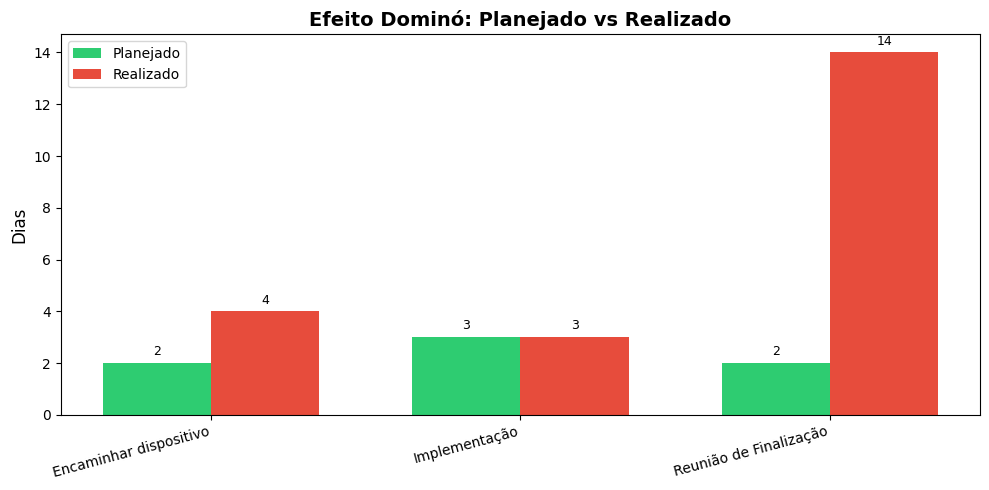

In [4]:
import pandas as pd

# Dados reais do seu projeto (extraídos do PDF)
dados_causa_raiz = pd.DataFrame({
    'Etapa': ['Encaminhar dispositivo', 'Implementação', 'Reunião de Finalização'],
    'Planejado (dias)': [2, 3, 2],
    'Realizado (dias)': [4, 3, 14],
    'Atraso (dias)': [2, 0, 12],
    'Causa do atraso': [
        'Dispositivo não disponível',
        'Aguardando etapa anterior',
        'Acúmulo de atrasos + reagendamento'
    ]
})

print("=" * 60)
print("🔍 ANÁLISE DE CAUSA RAIZ (Efeito Dominó)")
print("=" * 60)
print(dados_causa_raiz.to_string(index=False))

# Gráfico de barras mostrando o efeito dominó
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(dados_causa_raiz))
width = 0.35

ax.bar([i - width/2 for i in x], dados_causa_raiz['Planejado (dias)'], width, 
       label='Planejado', color='#2ecc71')
ax.bar([i + width/2 for i in x], dados_causa_raiz['Realizado (dias)'], width, 
       label='Realizado', color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(dados_causa_raiz['Etapa'], rotation=15, ha='right')
ax.set_ylabel('Dias', fontsize=12)
ax.set_title('Efeito Dominó: Planejado vs Realizado', fontsize=14, fontweight='bold')
ax.legend()

# Adicionar valores nas barras
for i, row in dados_causa_raiz.iterrows():
    ax.text(i - width/2, row['Planejado (dias)'] + 0.3, f"{row['Planejado (dias)']}", 
            ha='center', fontsize=9)
    ax.text(i + width/2, row['Realizado (dias)'] + 0.3, f"{row['Realizado (dias)']}", 
            ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('efeito_domino.png', dpi=150, bbox_inches='tight')
plt.show()


📋 SUGESTÕES DE OTIMIZAÇÃO - CHECKPOINT 3
 Ordem                                                           Ação         Responsável         Prazo         Impacto esperado
     1 Antecipar pedido de dispositivo em 3 dias antes da necessidade Gerente de Projetos      Imediato Reduzir 4 dias de atraso
     2                  Criar checklist padronizada para configuração          Time de TI       15 dias        Evitar retrabalho
     3         Dividir reunião de finalização em 2 encontros semanais                 PMO Próximo ciclo     Reduzir 50% do tempo
     4              Implementar buffer de 2 dias após etapas críticas         Coordenador       30 dias       Absorver variações


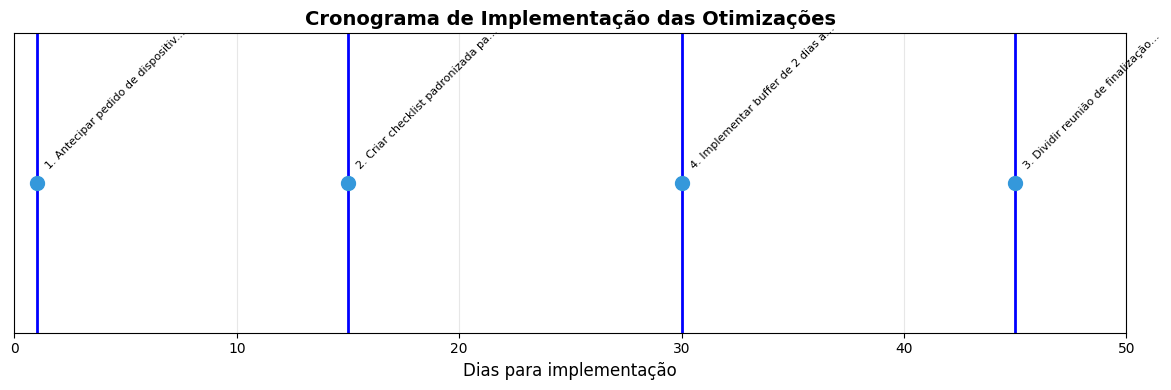

In [5]:
import pandas as pd
from datetime import datetime

# Tabela de sugestões de otimização
sugestoes = pd.DataFrame({
    'Ordem': [1, 2, 3, 4],
    'Ação': [
        'Antecipar pedido de dispositivo em 3 dias antes da necessidade',
        'Criar checklist padronizada para configuração',
        'Dividir reunião de finalização em 2 encontros semanais',
        'Implementar buffer de 2 dias após etapas críticas'
    ],
    'Responsável': ['Gerente de Projetos', 'Time de TI', 'PMO', 'Coordenador'],
    'Prazo': ['Imediato', '15 dias', 'Próximo ciclo', '30 dias'],
    'Impacto esperado': ['Reduzir 4 dias de atraso', 'Evitar retrabalho', 'Reduzir 50% do tempo', 'Absorver variações']
})

print("\n" + "=" * 70)
print("📋 SUGESTÕES DE OTIMIZAÇÃO - CHECKPOINT 3")
print("=" * 70)
print(sugestoes.to_string(index=False))

# Gráfico de linha do tempo das ações
fig, ax = plt.subplots(figsize=(12, 4))

prazos = {
    'Imediato': 1,
    '15 dias': 15,
    '30 dias': 30,
    'Próximo ciclo': 45
}

sugestoes['Dias'] = sugestoes['Prazo'].map(prazos)
sugestoes_sorted = sugestoes.sort_values('Dias')

# Criar linha do tempo
for idx, row in sugestoes_sorted.iterrows():
    ax.plot([row['Dias'], row['Dias']], [0, 1], 'b-', linewidth=2)
    ax.scatter(row['Dias'], 0.5, s=100, color='#3498db', zorder=5)
    ax.annotate(f"{row['Ordem']}. {row['Ação'][:30]}...", 
                xy=(row['Dias'], 0.5), xytext=(5, 10),
                textcoords="offset points", fontsize=8, rotation=45)

ax.set_xlim(0, 50)
ax.set_ylim(0, 1)
ax.set_xlabel('Dias para implementação', fontsize=12)
ax.set_title('Cronograma de Implementação das Otimizações', fontsize=14, fontweight='bold')
ax.set_yticks([])
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('cronograma_otimizacoes.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
import pandas as pd

sugestoes = pd.DataFrame({
    'Ordem': [1, 2, 3, 4],
    'Ação': [
        'Antecipar pedido de dispositivo em 3 dias antes da necessidade',
        'Criar checklist padronizada para configuração',
        'Dividir reunião de finalização em 2 encontros semanais',
        'Implementar buffer de 2 dias após etapas críticas'
    ],
    'Responsável': ['Gerente de Projetos', 'Time de TI', 'PMO', 'Coordenador'],
    'Prazo': ['Imediato', '15 dias', 'Próximo ciclo', '30 dias'],
    'Impacto esperado': ['Reduzir 4 dias de atraso', 'Evitar retrabalho', 'Reduzir 50% do tempo', 'Absorver variações']
})

print("\n" + "=" * 70)
print("📋 SUGESTÕES DE OTIMIZAÇÃO - CHECKPOINT 3")
print("=" * 70)
print(sugestoes.to_string(index=False))


📋 SUGESTÕES DE OTIMIZAÇÃO - CHECKPOINT 3
 Ordem                                                           Ação         Responsável         Prazo         Impacto esperado
     1 Antecipar pedido de dispositivo em 3 dias antes da necessidade Gerente de Projetos      Imediato Reduzir 4 dias de atraso
     2                  Criar checklist padronizada para configuração          Time de TI       15 dias        Evitar retrabalho
     3         Dividir reunião de finalização em 2 encontros semanais                 PMO Próximo ciclo     Reduzir 50% do tempo
     4              Implementar buffer de 2 dias após etapas críticas         Coordenador       30 dias       Absorver variações


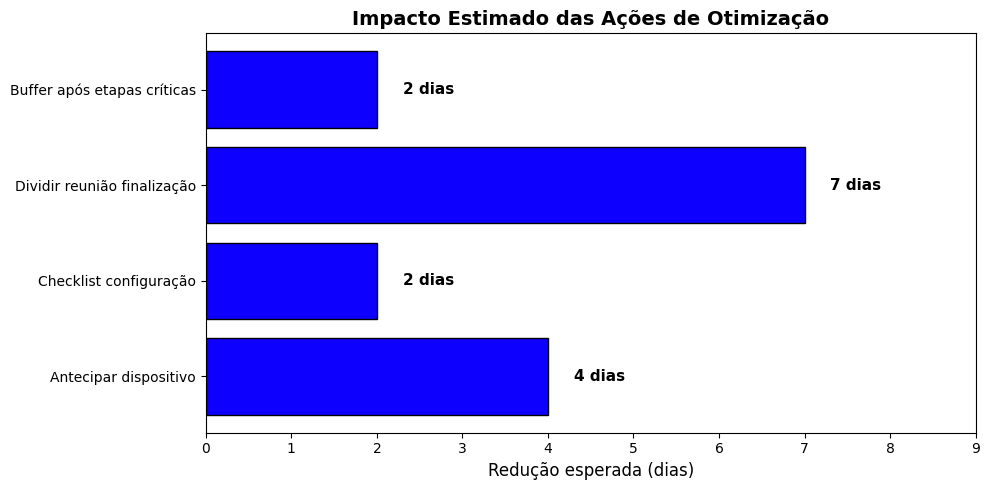

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Dados
impactos = pd.DataFrame({
    'Ação': [
        'Antecipar dispositivo',
        'Checklist configuração',
        'Dividir reunião finalização',
        'Buffer após etapas críticas'
    ],
    'Redução de dias': [4, 2, 7, 2]
})

fig, ax = plt.subplots(figsize=(10, 5))

# Tons de azul fixos
cores_azuis = ["#0d00ff", "#0d00ff", "#0d00ff", "#0d00ff"]

ax.barh(impactos['Ação'], impactos['Redução de dias'], color=cores_azuis, edgecolor='black', linewidth=1)
ax.set_xlabel('Redução esperada (dias)', fontsize=12)
ax.set_title('Impacto Estimado das Ações de Otimização', fontsize=14, fontweight='bold')

for i, v in enumerate(impactos['Redução de dias']):
    ax.text(v + 0.3, i, f'{v} dias', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, impactos['Redução de dias'].max() + 2)

plt.tight_layout()
plt.savefig('impacto_otimizacoes.png', dpi=150, bbox_inches='tight')
plt.show()

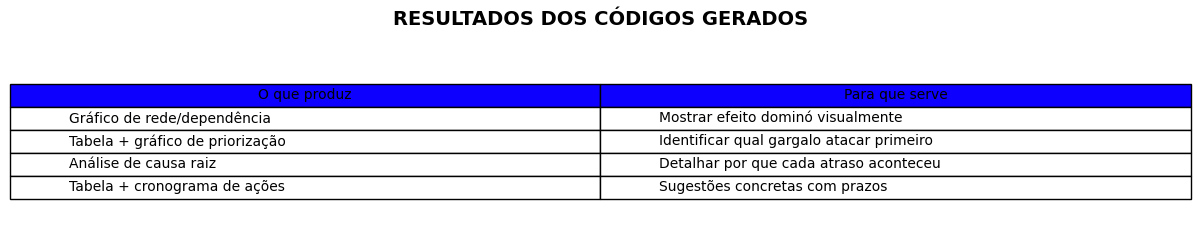

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.table import Table

# Dados da tabela
dados = {
    'O que produz': [
        'Gráfico de rede/dependência',
        'Tabela + gráfico de priorização',
        'Análise de causa raiz',
        'Tabela + cronograma de ações'
    ],
    'Para que serve': [
        'Mostrar efeito dominó visualmente',
        'Identificar qual gargalo atacar primeiro',
        'Detalhar por que cada atraso aconteceu',
        'Sugestões concretas com prazos'
    ]
}

df = pd.DataFrame(dados)

# Criar figura
fig, ax = plt.subplots(figsize=(12, 2.5))
ax.axis('off')
ax.axis('tight')

# Criar tabela
tabela = ax.table(cellText=df.values, colLabels=df.columns, 
                  cellLoc='left', loc='center',
                  colColours=['#0d00ff', '#0d00ff', '#0d00ff'])

# Estilizar
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.5)

plt.title('RESULTADOS DOS CÓDIGOS GERADOS', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('tabela_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

AttributeError: 'Table' object has no attribute 'get_cell_dict'

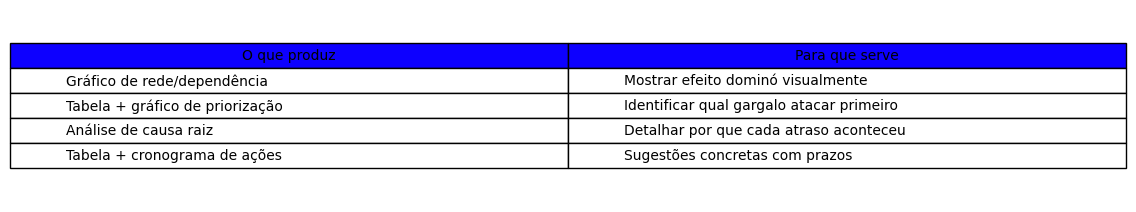

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.table import Table

# Dados da tabela
dados = {
    'O que produz': [
        'Gráfico de rede/dependência',
        'Tabela + gráfico de priorização',
        'Análise de causa raiz',
        'Tabela + cronograma de ações'
    ],
    'Para que serve': [
        'Mostrar efeito dominó visualmente',
        'Identificar qual gargalo atacar primeiro',
        'Detalhar por que cada atraso aconteceu',
        'Sugestões concretas com prazos'
    ]
}

df = pd.DataFrame(dados)

# Criar figura
fig, ax = plt.subplots(figsize=(12, 2.5))
ax.axis('off')
ax.axis('tight')

# Criar tabela
tabela = ax.table(cellText=df.values, colLabels=df.columns, 
                  cellLoc='left', loc='center',
                  colColours=['#0d00ff', '#0d00ff'])

# Estilizar
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.5)

# FORÇAR COR DO TEXTO PARA BRANCO NAS CÉLULAS COM FUNDO ESCURO
for (row, col), cell in tabela.get_cell_dict().items():
    if row == 0:  # Cabeçalho (linha 0)
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#0d00ff')
    else:  # Corpo da tabela
        cell.set_text_props(color='white')
        cell.set_facecolor('#4d42ff')  # tom mais claro para o corpo

plt.title('RESULTADOS DOS CÓDIGOS GERADOS', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('tabela_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

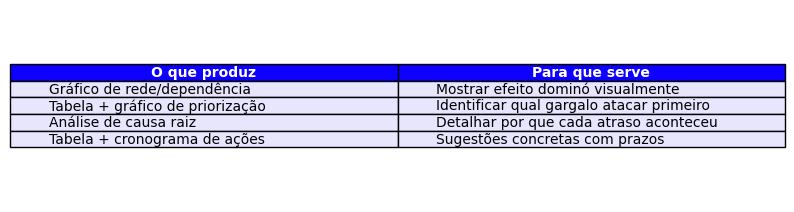

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Dados
dados = {
    'O que produz': [
        'Gráfico de rede/dependência',
        'Tabela + gráfico de priorização',
        'Análise de causa raiz',
        'Tabela + cronograma de ações'
    ],
    'Para que serve': [
        'Mostrar efeito dominó visualmente',
        'Identificar qual gargalo atacar primeiro',
        'Detalhar por que cada atraso aconteceu',
        'Sugestões concretas com prazos'
    ]
}

df = pd.DataFrame(dados)

# Criar figura
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis('tight')
ax.axis('off')

# Criar tabela
tabela = ax.table(cellText=df.values,
                  colLabels=df.columns,
                  cellLoc='left',
                  loc='center')

# Ajustar tamanho
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)

# Pintar cabeçalho
for j in range(len(df.columns)):
    tabela[(0, j)].set_facecolor('#0d00ff')
    tabela[(0, j)].set_text_props(color='white', fontweight='bold')

# Pintar corpo
for i in range(len(df)):
    for j in range(len(df.columns)):
        tabela[(i+1, j)].set_facecolor('#e8e6ff')
        tabela[(i+1, j)].set_text_props(color='black')

plt.show()

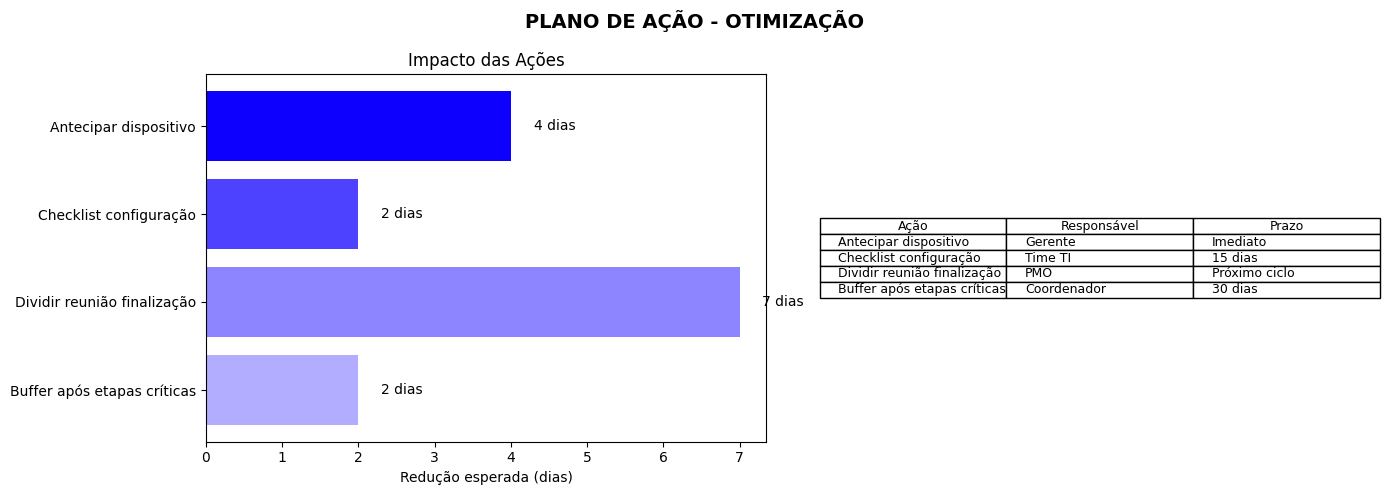

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Dados
df = pd.DataFrame({
    'Ação': [
                'Antecipar dispositivo',
                'Checklist configuração',
                'Dividir reunião finalização',
                'Buffer após etapas críticas'
    ],
    'Responsável': ['Gerente', 'Time TI', 'PMO', 'Coordenador'],
    'Prazo': ['Imediato', '15 dias', 'Próximo ciclo', '30 dias'],
    'Redução_dias': [4, 2, 7, 2]
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico
cores = ['#0d00ff', '#4d42ff', '#8c85ff', '#b3adff']
barras = ax1.barh(df['Ação'], df['Redução_dias'], color=cores)
ax1.set_xlabel('Redução esperada (dias)')
ax1.set_title('Impacto das Ações')
ax1.invert_yaxis()
for barra, valor in zip(barras, df['Redução_dias']):
    ax1.text(valor + 0.3, barra.get_y() + barra.get_height()/2, f'{valor} dias', va='center')

# Tabela
ax2.axis('off')
tabela = ax2.table(cellText=df[['Ação', 'Responsável', 'Prazo']].values,
                   colLabels=['Ação', 'Responsável', 'Prazo'],
                   cellLoc='left', loc='center')
tabela.auto_set_font_size(False)
tabela.set_fontsize(9)

plt.suptitle('PLANO DE AÇÃO - OTIMIZAÇÃO', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plano_acao.png', dpi=150, bbox_inches='tight')
plt.show()

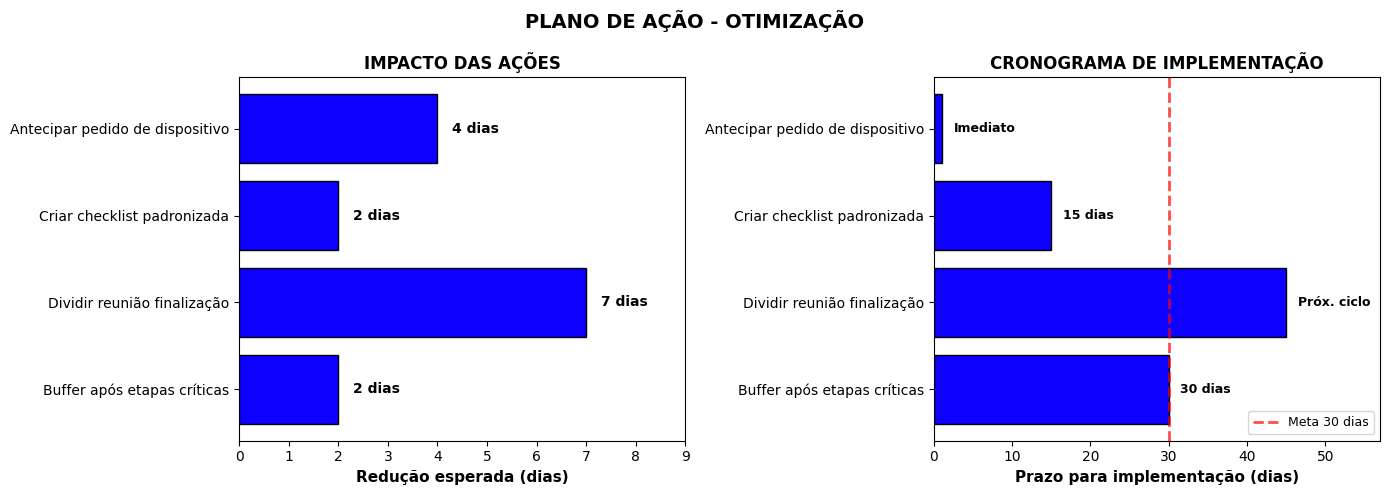

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Dados
df = pd.DataFrame({
    'Ação': [
        'Antecipar pedido de dispositivo',
        'Criar checklist padronizada',
        'Dividir reunião finalização',
        'Buffer após etapas críticas'
    ],
    'Responsável': ['Gerente Projetos', 'Time Operacional', 'PMO', 'Coordenador'],
    'Prazo': ['Imediato', '15 dias', 'Próx. ciclo', '30 dias'],  # TEXTO ENCURTADO
    'Impacto': ['Reduz 4 dias', 'Evita retrabalho', 'Reduz 50% tempo', 'Absorve variações'],
    'Redução_dias': [4, 2, 7, 2],
    'Dias_prazo': [1, 15, 45, 30]
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# =========================================
# GRÁFICO 1: Impacto
# =========================================
cores = ['#0d00ff', '#0d00ff', '#0d00ff', '#0d00ff']
barras = ax1.barh(df['Ação'], df['Redução_dias'], color=cores, edgecolor='black', linewidth=1)
ax1.set_xlabel('Redução esperada (dias)', fontsize=11, fontweight='bold')
ax1.set_title('IMPACTO DAS AÇÕES', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

for barra, valor in zip(barras, df['Redução_dias']):
    ax1.text(valor + 0.3, barra.get_y() + barra.get_height()/2, 
             f'{valor} dias', va='center', fontsize=10, fontweight='bold')

# Ajustar limite do eixo X para caber o texto
ax1.set_xlim(0, df['Redução_dias'].max() + 2)

# =========================================
# GRÁFICO 2: Cronograma (CORRIGIDO)
# =========================================
for i, row in df.iterrows():
    cor = cores[i]
    ax2.barh(row['Ação'], row['Dias_prazo'], color=cor, edgecolor='black', linewidth=1)
    
    # Posicionar texto FORA da barra (à direita)
    ax2.text(row['Dias_prazo'] + 1.5, i, row['Prazo'], 
             va='center', fontsize=9, fontweight='bold')

ax2.set_xlabel('Prazo para implementação (dias)', fontsize=11, fontweight='bold')
ax2.set_title('CRONOGRAMA DE IMPLEMENTAÇÃO', fontsize=12, fontweight='bold')
ax2.invert_yaxis()
ax2.axvline(x=30, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Meta 30 dias')
ax2.legend(loc='lower right', fontsize=9)

# Ajustar limite do eixo X para caber o texto "Próx. ciclo"
ax2.set_xlim(0, df['Dias_prazo'].max() + 12)

plt.suptitle('PLANO DE AÇÃO - OTIMIZAÇÃO', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plano_acao_corrigido.png', dpi=150, bbox_inches='tight')
plt.show()

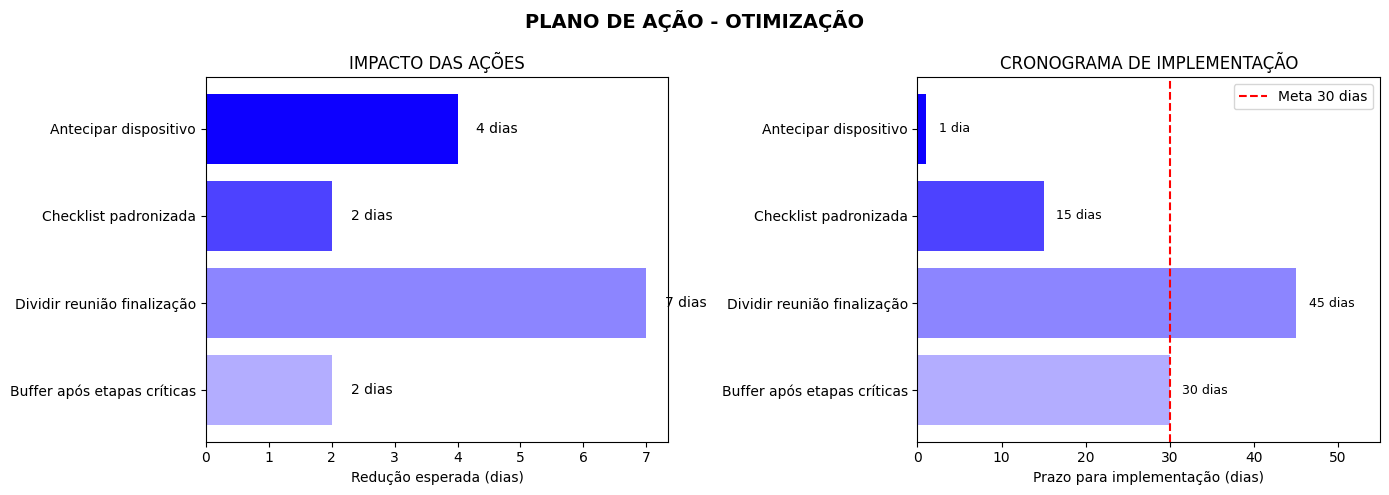

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Dados com prazos simplificados
df = pd.DataFrame({
    'Ação': [
        'Antecipar dispositivo',
        'Checklist padronizada',
        'Dividir reunião finalização',
        'Buffer após etapas críticas'
    ],
    'Prazo_num': [1, 15, 45, 30],
    'Prazo_txt': ['1 dia', '15 dias', '45 dias', '30 dias'],
    'Redução_dias': [4, 2, 7, 2]
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Impacto
cores = ['#0d00ff', '#4d42ff', '#8c85ff', '#b3adff']
barras = ax1.barh(df['Ação'], df['Redução_dias'], color=cores)
ax1.set_xlabel('Redução esperada (dias)')
ax1.set_title('IMPACTO DAS AÇÕES')
ax1.invert_yaxis()
for barra, valor in zip(barras, df['Redução_dias']):
    ax1.text(valor + 0.3, barra.get_y() + barra.get_height()/2, f'{valor} dias', va='center')

# Gráfico 2: Cronograma
for i, row in df.iterrows():
    ax2.barh(row['Ação'], row['Prazo_num'], color=cores[i])
    ax2.text(row['Prazo_num'] + 1.5, i, row['Prazo_txt'], va='center', fontsize=9)

ax2.set_xlabel('Prazo para implementação (dias)')
ax2.set_title('CRONOGRAMA DE IMPLEMENTAÇÃO')
ax2.invert_yaxis()
ax2.axvline(x=30, color='red', linestyle='--', label='Meta 30 dias')
ax2.legend()
ax2.set_xlim(0, 55)

plt.suptitle('PLANO DE AÇÃO - OTIMIZAÇÃO', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plano_acao_simples.png', dpi=150, bbox_inches='tight')
plt.show()